In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !unzip /content/drive/MyDrive/dog_images_asis.zip -d /content/drive/MyDrive/DOG_BREED_IDENTIFICATION

In [3]:
import os

os.mkdir('/content/DOG_BREED_IDENTIFICATION/')

In [4]:
!cp -r /content/drive/MyDrive/DOG_BREED_IDENTIFICATION/* /content/DOG_BREED_IDENTIFICATION/

In [282]:
print(len(os.listdir('/content/DOG_BREED_IDENTIFICATION/dog_images')))
print(len(os.listdir('/content/DOG_BREED_IDENTIFICATION')))

10222
4


In [283]:
import pandas as pd
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow.keras as tfk
import tensorflow.keras.layers as tfl

In [307]:
data = pd.read_csv("/content/DOG_BREED_IDENTIFICATION/labels.csv")

In [308]:
image_dir = '/content/DOG_BREED_IDENTIFICATION/dog_images'

In [309]:
data["filename"] = data["id"].astype(str) + ".jpg"

breed_labels = {breed: idx for idx, breed in enumerate(sorted(data["breed"].unique()))}
data["label"] = data["breed"].map(breed_labels)

In [310]:
data.head()

,id,breed,filename,label
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull,000bec180eb18c7604dcecc8fe0dba07.jpg,19
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo,001513dfcb2ffafc82cccf4d8bbaba97.jpg,37
2,001cdf01b096e06d78e9e5112d419397,pekinese,001cdf01b096e06d78e9e5112d419397.jpg,85
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick,00214f311d5d2247d5dfe4fe24b2303d.jpg,15
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever,0021f9ceb3235effd7fcde7f7538ed62.jpg,49


In [311]:
breed_labels

{'affenpinscher': 0,
 'afghan_hound': 1,
 'african_hunting_dog': 2,
 'airedale': 3,
 'american_staffordshire_terrier': 4,
 'appenzeller': 5,
 'australian_terrier': 6,
 'basenji': 7,
 'basset': 8,
 'beagle': 9,
 'bedlington_terrier': 10,
 'bernese_mountain_dog': 11,
 'black-and-tan_coonhound': 12,
 'blenheim_spaniel': 13,
 'bloodhound': 14,
 'bluetick': 15,
 'border_collie': 16,
 'border_terrier': 17,
 'borzoi': 18,
 'boston_bull': 19,
 'bouvier_des_flandres': 20,
 'boxer': 21,
 'brabancon_griffon': 22,
 'briard': 23,
 'brittany_spaniel': 24,
 'bull_mastiff': 25,
 'cairn': 26,
 'cardigan': 27,
 'chesapeake_bay_retriever': 28,
 'chihuahua': 29,
 'chow': 30,
 'clumber': 31,
 'cocker_spaniel': 32,
 'collie': 33,
 'curly-coated_retriever': 34,
 'dandie_dinmont': 35,
 'dhole': 36,
 'dingo': 37,
 'doberman': 38,
 'english_foxhound': 39,
 'english_setter': 40,
 'english_springer': 41,
 'entlebucher': 42,
 'eskimo_dog': 43,
 'flat-coated_retriever': 44,
 'french_bulldog': 45,
 'german_shepherd'

In [312]:
IMG_SIZE = (224, 224)

@tf.function
def load_image(image_path):
  image = tf.io.read_file(image_path)
  image = tf.image.decode_image(image, channels=3, dtype=tf.uint8, expand_animations=False)
  image = tf.image.resize(image, IMG_SIZE)
  return image

@tf.function
def load_data(image_path, image_label):
  return load_image(image_path), image_label

In [313]:
train_data, test_data = train_test_split(data, test_size=0.15, stratify=data["label"], random_state=59)
train_data, val_data = train_test_split(train_data, test_size=0.2, stratify=train_data["label"], random_state=60)

train_image_paths = [os.path.join(image_dir, fname) for fname in train_data["filename"].tolist()]
test_image_paths = [os.path.join(image_dir, fname) for fname in test_data["filename"].tolist()]
val_image_paths = [os.path.join(image_dir, fname) for fname in val_data["filename"].tolist()]

train_labels = train_data["label"].tolist()
test_labels = test_data["label"].tolist()
val_labels = val_data["label"].tolist()

In [314]:
len(train_image_paths), len(train_labels), len(test_image_paths), len(test_labels), len(val_image_paths), len(val_labels)

(6950, 6950, 1534, 1534, 1738, 1738)

In [315]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_image_paths, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_image_paths, test_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_image_paths, val_labels))

In [316]:
batch_size = 32

train_dataset = train_dataset.shuffle(buffer_size=train_dataset.cardinality(), seed=61, reshuffle_each_iteration=True)\
                             .map(load_data, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .prefetch(buffer_size=tf.data.AUTOTUNE)

val_dataset   =   val_dataset.shuffle(buffer_size=val_dataset.cardinality(), seed=62, reshuffle_each_iteration=True)\
                             .map(load_data, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .prefetch(buffer_size=tf.data.AUTOTUNE)

test_dataset  =  test_dataset.shuffle(buffer_size=test_dataset.cardinality(), seed=63, reshuffle_each_iteration=True)\
                             .map(load_data, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .batch(batch_size, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True)\
                             .prefetch(buffer_size=tf.data.AUTOTUNE)

print(train_dataset.cardinality().numpy(), val_dataset.cardinality().numpy(), test_dataset.cardinality().numpy())

218 55 48


In [317]:
IMG_SHAPE = IMG_SIZE + (3,)

In [318]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip(),
  tf.keras.layers.RandomRotation(factor=0.2),
  tf.keras.layers.RandomContrast(factor=0.2),
  tf.keras.layers.RandomBrightness(factor=0.2)
  ])

In [319]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

In [320]:
base_model = tf.keras.applications.MobileNetV2(
  input_shape=IMG_SHAPE,
  include_top=False,
  weights='imagenet',
  input_tensor=None,
  pooling='avg'
)

In [321]:
base_model.trainable = False

In [324]:
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.Dropout(0.5)(x)
# x = tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tfk.regularizers.l2(0.01))(x)
outputs = tf.keras.layers.Dense(len(breed_labels))(x)
model = tf.keras.Model(inputs, outputs, name='dog_breed_classifier')

In [325]:
model.summary()

Model: "dog_breed_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_38 (InputLayer)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_12 (Sequential)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide_17 (TrueDivide)          │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract_17 (Subtract)               │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 1280)                │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 120)                 │         153,720 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,411,704 (9.20 MB)

 Trainable params: 153,720 (600.47 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [326]:
model.compile(
  optimizer=tfk.optimizers.Adam(learning_rate=1e-3),
  loss=tfk.losses.SparseCategoricalCrossentropy(from_logits=True, name='sparse_categorical_crossentropy'),
  metrics=[tfk.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

In [327]:
loss0, accuracy0 = model.evaluate(test_dataset)

print("initial loss: {:.2f}".format(loss0))
print("initial accuracy: {:.2f}".format(accuracy0))

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.0077 - loss: 5.1056
initial loss: 5.10
initial accuracy: 0.01


In [328]:
callbacks = [
  tfk.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models5/model_epoch_{epoch:03}.keras',
    save_best_only=False,
    save_weights_only=False,
    monitor='val_loss',
    mode='min',
    verbose=0
  ),
  tfk.callbacks.EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss',
    mode='min',
    verbose=1,
    start_from_epoch=12
  )
]

In [329]:
history = model.fit(
  train_dataset,
  epochs=25,
  verbose=2,
  validation_data=val_dataset,
  callbacks=callbacks
)

Epoch 1/25
218/218 - 24s - 110ms/step - accuracy: 0.1741 - loss: 3.8203 - val_accuracy: 0.6628 - val_loss: 1.5472
Epoch 2/25
218/218 - 21s - 96ms/step - accuracy: 0.3744 - loss: 2.4615 - val_accuracy: 0.7399 - val_loss: 1.0397
Epoch 3/25
218/218 - 20s - 94ms/step - accuracy: 0.4419 - loss: 2.1669 - val_accuracy: 0.7578 - val_loss: 0.9033
Epoch 4/25
218/218 - 18s - 82ms/step - accuracy: 0.4780 - loss: 1.9593 - val_accuracy: 0.7641 - val_loss: 0.8254
Epoch 5/25
218/218 - 18s - 82ms/step - accuracy: 0.5020 - loss: 1.9056 - val_accuracy: 0.7710 - val_loss: 0.7823
Epoch 6/25
218/218 - 22s - 99ms/step - accuracy: 0.5201 - loss: 1.8055 - val_accuracy: 0.7819 - val_loss: 0.7633
Epoch 7/25
218/218 - 19s - 89ms/step - accuracy: 0.5319 - loss: 1.7383 - val_accuracy: 0.7704 - val_loss: 0.7608
Epoch 8/25
218/218 - 20s - 93ms/step - accuracy: 0.5334 - loss: 1.7039 - val_accuracy: 0.7888 - val_loss: 0.7413
Epoch 9/25
218/218 - 19s - 88ms/step - accuracy: 0.5498 - loss: 1.6687 - val_accuracy: 0.7808 -

In [330]:
model.save("/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models5/complete_model.keras")

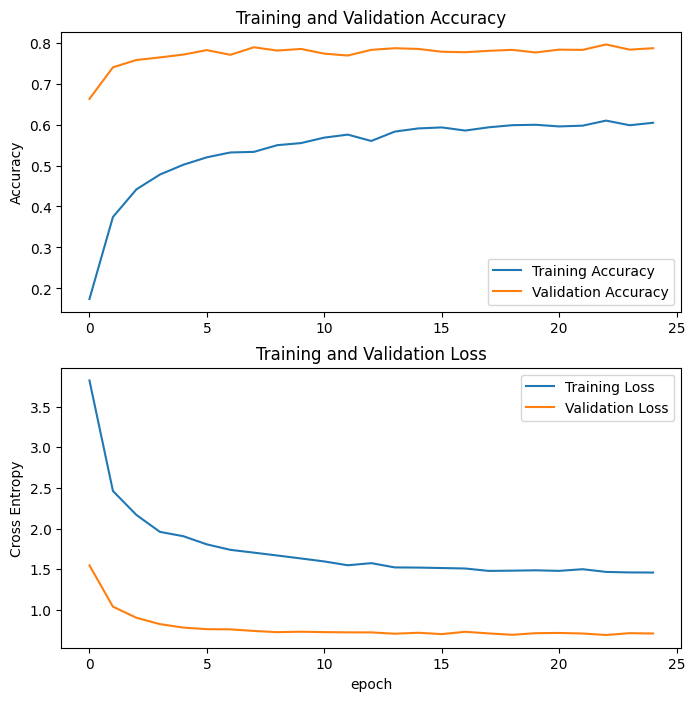

In [331]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
# plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
# plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [332]:
loss1, accuracy1 = model.evaluate(test_dataset)
print(loss1, accuracy1)

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7565 - loss: 0.7937
0.7420442700386047 0.7764015793800354


In [ ]:
tfk.utils.plot_model(model, to_file='/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/model5.png', show_layer_activations=True, show_layer_names=True, show_shapes=True, show_trainable=True)

In [ ]:
tfk.utils.plot_model(model.layers[2], to_file='/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/base_model5.png', show_layer_activations=True, show_layer_names=True, show_shapes=True, show_trainable=True)

## fine tuning

In [98]:
base_model.trainable = True

In [ ]:
base_model.layers[-4:]

In [100]:
for layer in base_model.layers[:-4]:
  layer.trainable = False

In [101]:
model.compile(
    optimizer=tfk.optimizers.Adam(learning_rate=1e-7),
    loss=tfk.losses.SparseCategoricalCrossentropy(from_logits=True, name='sparse_categorical_crossentropy'),
    metrics=[tfk.metrics.SparseCategoricalAccuracy(name='accuracy')]
)

In [ ]:
tfk.utils.plot_model(model, to_file='/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/model2.png', show_layer_activations=True, show_layer_names=True, show_shapes=True, show_trainable=True)

In [ ]:
tfk.utils.plot_model(model.layers[2], to_file='/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/base_model2.png', show_layer_activations=True, show_layer_names=True, show_shapes=True, show_trainable=True)

In [102]:
callbacks = [
    tfk.callbacks.ModelCheckpoint(
        '/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models6/model_epoch_{epoch:03}.keras',
        save_best_only=False,
        save_weights_only=False,
        monitor='val_loss',
        mode='min',
        verbose=0
    ),
    tfk.callbacks.EarlyStopping(
        patience=7,
        restore_best_weights=True,
        monitor='val_loss',
        mode='min',
        verbose=1,
        start_from_epoch=15
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    epochs=50,
    verbose=2,
    validation_data=val_dataset,
    callbacks=callbacks
)

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
# plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
# plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
loss2, accuracy2 = model.evaluate(test_dataset)
print(loss2, accuracy2)

In [ ]:
model.save("/content/drive/MyDrive/DOG_BREED_IDENTIFICATION/models6/complete_model.keras")

In [ ]:
from google.colab import runtime
runtime.unassign()